In [2]:
# v. imp
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import PolynomialFeatures

In [3]:
df=pd.read_csv('windpower.csv')
df

,Power (kW),Wind speed (m/s)
0,0.0,0.000
1,0.0,0.125
2,0.0,0.150
3,0.0,0.225
4,0.0,0.275
...,...,...
495,0.0,24.775
496,0.0,24.850
497,0.0,24.875
498,0.0,24.950


In [4]:
df.isna().sum()

Power (kW)          3
Wind speed (m/s)    5
dtype: int64

In [5]:
df=df.dropna()
df.isna().sum()

Power (kW)          0
Wind speed (m/s)    0
dtype: int64

In [6]:
y=df["Power (kW)"]
x=df[["Wind speed (m/s)"]]

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((369, 1), (123, 1), (369,), (123,))

Degree =  3
MSE =  270.0250095299955
R2_score =  0.8539264141973832

Degree =  4
MSE =  209.3184510784717
R2_score =  0.8867664266472862

Degree =  5
MSE =  212.4228861347375
R2_score =  0.8850870416105098

Degree =  6
MSE =  169.170104193283
R2_score =  0.9084852037478769



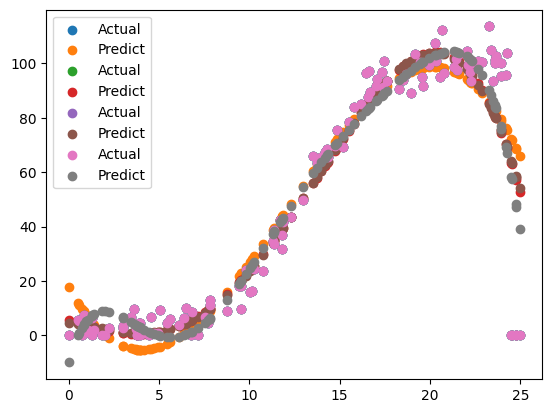

In [10]:
degree=[3,4,5,6]
MSE=[]
for i in degree:
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    lr=LinearRegression()
    lr.fit(x_train_poly,y_train)
    x_test_poly=poly.transform(x_test)
    y_pred=lr.predict(x_test_poly)
    mse=mean_squared_error(y_test,y_pred)
    MSE.append(mse)
    R2_score=r2_score(y_test,y_pred)
    print("Degree = ",i)
    print("MSE = ",mse)
    print("R2_score = ",R2_score)
    print()
    plt.scatter(x_test,y_test,label="Actual")
    plt.scatter(x_test,y_pred,label="Predict")
plt.legend()
plt.show()


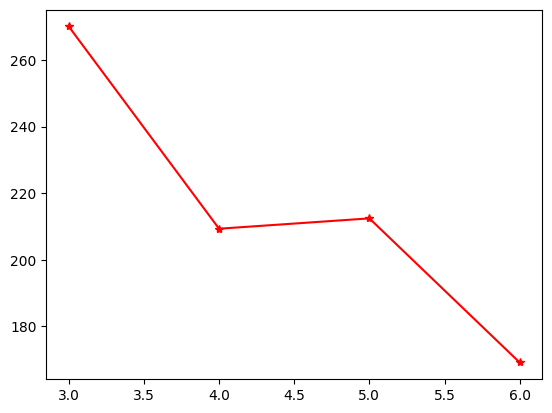

In [9]:
plt.plot(degree,MSE,'*-r')
plt.show()